# ProfitPilot Local 5m Multi-Asset PPO Training

This notebook is built for a local Jupyter or VS Code kernel. It downloads BTC/USDT and ETH/USDT 5-minute candles from `2024-01-01` through `2026-04-28`, trains the RL trading model on `2024-01-01` through `2026-03-30`, and tests out of sample on `2026-04-01` through `2026-04-28`.



In [4]:
# Colab setup. This keeps Colab's CUDA PyTorch build intact and installs only the project dependencies.
%pip install -q ccxt ta stable-baselines3 sb3-contrib gymnasium pyarrow seaborn python-dotenv PyYAML

# This installs the project runtime dependencies from the nearest requirements.txt file.
import subprocess
import sys
from pathlib import Path

requirements_root = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'requirements.txt').exists()), None)
if requirements_root is None:
    print('requirements.txt not found. Start the notebook from the ProfitPilot folder or install dependencies manually.')
else:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(requirements_root / 'requirements.txt')])
    print(f'Installed/verified dependencies from {requirements_root / "requirements.txt"}')


Note: you may need to restart the kernel to use updated packages.


Installed/verified dependencies from /requirements.txt


In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
import warnings


def find_project_root() -> Path:
    candidates = []
    env_root = os.environ.get('PROFIT_PILOT_ROOT')
    if env_root:
        candidates.append(Path(env_root).expanduser())
    candidates.append(Path.cwd())

    for candidate in list(candidates):
        candidates.extend(candidate.parents)

    seen = set()
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except OSError:
            continue
        if resolved in seen:
            continue
        seen.add(resolved)
        if (resolved / 'src' / 'profit_pilot').exists():
            return resolved

    raise FileNotFoundError(
        'Could not find ProfitPilot. Start the notebook from the project folder or set '
        'PROFIT_PILOT_ROOT to the local project path.'
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
print(f'Project root: {PROJECT_ROOT}')

import numpy as np
import pandas as pd
import torch
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {DEVICE}')
if DEVICE == 'cuda':
    if hasattr(torch, 'set_float32_matmul_precision'):
        torch.set_float32_matmul_precision('high')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA version: {torch.version.cuda}')
else:
    print('GPU not available; training will run on CPU unless your local environment has CUDA enabled.')


FileNotFoundError: Could not find ProfitPilot. Start the notebook from the project folder or set PROFIT_PILOT_ROOT to the local project path.

In [3]:
import importlib
import inspect

import ccxt
import matplotlib.pyplot as plt
import seaborn as sns
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.utils import set_random_seed
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

import profit_pilot.data.download_ohlcv as download_ohlcv_module
import profit_pilot.env.multi_crypto_env as multi_crypto_env_module
import profit_pilot.features.build_features as build_features_module
import profit_pilot.utils.io as io_module

# Colab/Jupyter can keep old modules in memory. Reload project modules so this run uses the current source files.
download_ohlcv_module = importlib.reload(download_ohlcv_module)
multi_crypto_env_module = importlib.reload(multi_crypto_env_module)
build_features_module = importlib.reload(build_features_module)
io_module = importlib.reload(io_module)

fetch_symbol_ohlcv = download_ohlcv_module.fetch_symbol_ohlcv
save_symbol_csv = download_ohlcv_module.save_symbol_csv
MultiCryptoTradingEnv = multi_crypto_env_module.MultiCryptoTradingEnv
BASE_FEATURE_COLUMNS = build_features_module.BASE_FEATURE_COLUMNS
add_technical_indicators = build_features_module.add_technical_indicators
align_frames = build_features_module.align_frames
build_arrays = build_features_module.build_arrays
bundle_directory = io_module.bundle_directory
save_json = io_module.save_json
symbol_slug = io_module.symbol_slug

if 'cash_target_allocation' not in inspect.getsource(MultiCryptoTradingEnv.__init__):
    raise RuntimeError(
        'Loaded an old MultiCryptoTradingEnv without cash_target_allocation support. '
        'Restart the runtime and make sure the latest src/profit_pilot/env/multi_crypto_env.py is present (must have cash_target_allocation mode).'
    )


def env_flag(name: str, default: bool = False) -> bool:
    value = os.environ.get(name)
    if value is None:
        return default
    return value.strip().lower() in {'1', 'true', 'yes', 'y', 'on'}


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_random_seed(SEED)

EXCHANGE_IDS = [
    exchange_id.strip()
    for exchange_id in os.environ.get('PROFIT_PILOT_EXCHANGES', 'binanceus,kucoin,okx,bybit,binance').split(',')
    if exchange_id.strip()
]
EXCHANGE_ID = EXCHANGE_IDS[0]
SYMBOLS = ['BTC/USDT', 'ETH/USDT']
TIMEFRAME = '5m'
DOWNLOAD_LIMIT = 1000

DATA_START_ISO = '2024-01-01T00:00:00Z'
TRAIN_END_ISO = '2026-03-30T23:55:00Z'
TEST_WARMUP_START_ISO = '2026-03-31T00:00:00Z'
TEST_START_ISO = '2026-04-01T00:00:00Z'
TEST_END_ISO = '2026-04-28T00:00:00Z'
DATA_END_ISO = TEST_END_ISO

INITIAL_CASH = 10_000.0
LOOKBACK = 96
TOTAL_TIMESTEPS = int(os.environ.get('PROFIT_PILOT_TOTAL_TIMESTEPS', '750000'))
TRAIN_MODEL = not env_flag('PROFIT_PILOT_SKIP_TRAINING', default=False)
USE_LSTM = env_flag('PROFIT_PILOT_USE_LSTM', default=True)
FORCE_REDOWNLOAD = env_flag('PROFIT_PILOT_FORCE_REDOWNLOAD', default=False)
RUN_FINAL_FULL_WINDOW_RETRAIN = env_flag('PROFIT_PILOT_FULL_WINDOW_RETRAIN', default=False)

RAW_ROOT = PROJECT_ROOT / 'data' / 'raw_local_5m_2024_2026'
PROCESSED_TRAIN_ROOT = PROJECT_ROOT / 'data' / 'processed_local_5m_train_2024_2026_0330'
PROCESSED_TEST_ROOT = PROJECT_ROOT / 'data' / 'processed_local_5m_eval_2026_0401_0428'
PROCESSED_FULL_ROOT = PROJECT_ROOT / 'data' / 'processed_local_5m_full_2024_2026_0428'
MODEL_DIR = PROJECT_ROOT / 'models' / 'local_5m_cash_allocation'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'local_5m_cash_allocation'
PLOT_DIR = REPORT_DIR / 'plots'
for path in [RAW_ROOT, PROCESSED_TRAIN_ROOT, PROCESSED_TEST_ROOT, PROCESSED_FULL_ROOT, MODEL_DIR, REPORT_DIR, PLOT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MODEL_NAME = f"profit_pilot_{'recurrent_' if USE_LSTM else ''}ppo_5m_local_2024_2026_cash_allocation"
MODEL_PATH = MODEL_DIR / MODEL_NAME

print(f'Exchange fallback order: {EXCHANGE_IDS}')
print(f'Train window: {DATA_START_ISO} to {TRAIN_END_ISO}')
print(f'Test window: {TEST_START_ISO} to {TEST_END_ISO} (warm-up starts {TEST_WARMUP_START_ISO})')
print(f'Total timesteps: {TOTAL_TIMESTEPS:,}')
print(f'Model name: {MODEL_NAME}')


2026-05-02 17:46:32.031007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777743992.411568     257 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777743992.516361     257 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777743993.403077     257 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777743993.403115     257 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777743993.403118     257 computation_placer.cc:177] computation placer alr

ModuleNotFoundError: No module named 'profit_pilot'

## Download and Cache 5m Market Data



In [ ]:
def create_market_data_exchange(exchange_id: str):
    exchange_class = getattr(ccxt, exchange_id)
    exchange = exchange_class({'enableRateLimit': True})
    exchange.timeout = 30_000
    return exchange


def read_cached_frame(path: Path) -> pd.DataFrame | None:
    if not path.exists() or FORCE_REDOWNLOAD:
        return None

    frame = pd.read_csv(path)
    if frame.empty or 'datetime' not in frame.columns:
        return None

    frame['datetime'] = pd.to_datetime(frame['datetime'], utc=True)
    start = pd.Timestamp(DATA_START_ISO)
    end = pd.Timestamp(DATA_END_ISO)
    if frame['datetime'].min() <= start and frame['datetime'].max() >= end - pd.Timedelta(minutes=5):
        return frame[(frame['datetime'] >= start) & (frame['datetime'] <= end)].copy()
    return None


def load_or_download_symbol(exchange, exchange_id: str, symbol: str) -> pd.DataFrame:
    target_path = RAW_ROOT / exchange_id / TIMEFRAME / f'{symbol_slug(symbol)}.csv'
    cached = read_cached_frame(target_path)
    if cached is not None:
        print(f'Using cached {symbol} from {exchange_id}: {len(cached):,} rows')
        return cached

    print(f'Downloading {symbol} {TIMEFRAME} from {exchange_id}: {DATA_START_ISO} to {DATA_END_ISO}')
    frame = fetch_symbol_ohlcv(
        exchange=exchange,
        symbol=symbol,
        timeframe=TIMEFRAME,
        since=DATA_START_ISO,
        until=DATA_END_ISO,
        limit=DOWNLOAD_LIMIT,
    )
    frame['datetime'] = pd.to_datetime(frame['datetime'], utc=True)
    saved_path = save_symbol_csv(frame, RAW_ROOT, exchange_id, TIMEFRAME, symbol)
    print(f'Saved {len(frame):,} rows to {saved_path}')
    return frame


def download_all_symbols_from_exchange(exchange_id: str) -> dict[str, pd.DataFrame]:
    exchange = create_market_data_exchange(exchange_id)
    try:
        exchange.load_markets()
        available_symbols = set(exchange.symbols or [])
        missing_symbols = [symbol for symbol in SYMBOLS if symbol not in available_symbols]
        if missing_symbols:
            raise ValueError(f'{exchange_id} does not list these symbols: {missing_symbols}')

        return {
            symbol: load_or_download_symbol(exchange, exchange_id, symbol)
            for symbol in SYMBOLS
        }
    finally:
        if hasattr(exchange, 'close'):
            exchange.close()


full_symbol_frames = None
download_errors = {}
for candidate_exchange_id in EXCHANGE_IDS:
    print(f'\nTrying exchange: {candidate_exchange_id}')
    try:
        candidate_frames = download_all_symbols_from_exchange(candidate_exchange_id)
        full_symbol_frames = candidate_frames
        EXCHANGE_ID = candidate_exchange_id
        print(f'Using exchange for this run: {EXCHANGE_ID}')
        break
    except Exception as exc:
        error_message = f'{type(exc).__name__}: {str(exc)}'
        download_errors[candidate_exchange_id] = error_message
        print(f'{candidate_exchange_id} failed: {error_message[:500]}')

if full_symbol_frames is None:
    display(pd.DataFrame(download_errors.items(), columns=['exchange', 'error']))
    raise RuntimeError(
        'No exchange in EXCHANGE_IDS could download all requested symbols. '
        'Try changing EXCHANGE_IDS in Cell 4, for example to ["kucoin", "okx", "bybit"].'
    )

coverage_rows = []
for symbol, frame in full_symbol_frames.items():
    coverage_rows.append({
        'exchange': EXCHANGE_ID,
        'symbol': symbol,
        'rows': len(frame),
        'first': frame['datetime'].min(),
        'last': frame['datetime'].max(),
    })



Trying exchange: binanceus
Using cached BTC/USDT from binanceus: 244,225 rows
Using cached ETH/USDT from binanceus: 244,225 rows
Using exchange for this run: binanceus


## Build Train and Test Feature Bundles



In [ ]:
def split_symbol_frames(frames: dict[str, pd.DataFrame], start_iso: str, end_iso: str, inclusive_end: bool) -> dict[str, pd.DataFrame]:
    start = pd.Timestamp(start_iso)
    end = pd.Timestamp(end_iso)
    split_frames = {}
    for symbol, frame in frames.items():
        working = frame.copy()
        working['datetime'] = pd.to_datetime(working['datetime'], utc=True)
        if inclusive_end:
            mask = (working['datetime'] >= start) & (working['datetime'] <= end)
        else:
            mask = (working['datetime'] >= start) & (working['datetime'] < end)
        split = working.loc[mask].sort_values('datetime').reset_index(drop=True)
        if split.empty:
            raise ValueError(f'No rows for {symbol} between {start_iso} and {end_iso}')
        split_frames[symbol] = split
    return split_frames


def build_normalized_feature_bundle(
    symbol_frames: dict[str, pd.DataFrame],
    processed_root: Path,
    source_start_iso: str,
    source_end_iso: str,
    label: str,
    normalization_stats: dict[str, np.ndarray] | None = None,
) -> tuple[dict, dict[str, np.ndarray]]:
    enriched_frames = {}
    for symbol, frame in symbol_frames.items():
        enriched = add_technical_indicators(frame)
        if enriched.empty:
            raise ValueError(f'Feature frame became empty after indicator warm-up: {symbol}')
        enriched_frames[symbol] = enriched

    timestamps, aligned_frames = align_frames(enriched_frames)
    price_array, raw_tech_array, feature_export = build_arrays(SYMBOLS, aligned_frames)

    if normalization_stats is None:
        tech_mean = raw_tech_array.mean(axis=0)
        tech_std = raw_tech_array.std(axis=0)
        tech_std = np.where(tech_std < 1e-8, 1.0, tech_std)
        normalization_stats = {'mean': tech_mean, 'std': tech_std}

    tech_array = ((raw_tech_array - normalization_stats['mean']) / normalization_stats['std']).astype(np.float32)
    price_array = price_array.astype(np.float32)

    output_dir = bundle_directory(processed_root, TIMEFRAME, SYMBOLS)
    output_dir.mkdir(parents=True, exist_ok=True)
    np.save(output_dir / 'price_array.npy', price_array)
    np.save(output_dir / 'tech_array.npy', tech_array)
    np.save(output_dir / 'tech_mean.npy', normalization_stats['mean'])
    np.save(output_dir / 'tech_std.npy', normalization_stats['std'])
    pd.DataFrame({'datetime': timestamps.astype(str)}).to_csv(output_dir / 'timestamps.csv', index=False)
    feature_export.to_parquet(output_dir / 'feature_frame.parquet', index=False)

    metadata = {
        'label': label,
        'symbols': SYMBOLS,
        'feature_columns_per_asset': BASE_FEATURE_COLUMNS,
        'n_assets': len(SYMBOLS),
        'n_features_per_asset': len(BASE_FEATURE_COLUMNS),
        'price_array_shape': list(price_array.shape),
        'tech_array_shape': list(tech_array.shape),
        'timeframe': TIMEFRAME,
        'source_since': source_start_iso,
        'source_until': source_end_iso,
        'first_timestamp_after_indicator_warmup': str(timestamps.min()),
        'last_timestamp': str(timestamps.max()),
        'normalization': 'standard_score_using_train_stats',
    }
    save_json(metadata, output_dir / 'metadata.json')

    bundle = {
        'root': output_dir,
        'price_array': price_array,
        'tech_array': tech_array,
        'timestamps': pd.DataFrame({'datetime': timestamps.astype(str)}),
        'metadata': metadata,
    }
    return bundle, normalization_stats


def slice_bundle_to_start_at(bundle: dict, start_iso: str, label: str) -> dict:
    timestamps = pd.to_datetime(bundle['timestamps']['datetime'], utc=True).reset_index(drop=True)
    start_timestamp = pd.Timestamp(start_iso)
    start_index = int(timestamps.searchsorted(start_timestamp, side='left'))
    slice_start = start_index - LOOKBACK + 1
    if slice_start < 0:
        raise ValueError('Not enough warm-up rows before the requested test start. Move TEST_WARMUP_START_ISO earlier.')

    sliced_timestamps = timestamps.iloc[slice_start:].reset_index(drop=True)
    first_portfolio_timestamp = sliced_timestamps.iloc[LOOKBACK - 1]
    if first_portfolio_timestamp < start_timestamp:
        raise ValueError(f'Test would start before requested date: {first_portfolio_timestamp}')
    if first_portfolio_timestamp > start_timestamp:
        print(f'First available test timestamp after warm-up: {first_portfolio_timestamp}')

    metadata = dict(bundle['metadata'])
    metadata.update({
        'label': label,
        'sliced_from_label': bundle['metadata']['label'],
        'requested_test_start': start_iso,
        'first_portfolio_timestamp': str(first_portfolio_timestamp),
        'warmup_rows_in_slice': int(LOOKBACK - 1),
        'price_array_shape': list(bundle['price_array'][slice_start:].shape),
        'tech_array_shape': list(bundle['tech_array'][slice_start:].shape),
        'last_timestamp': str(sliced_timestamps.max()),
    })

    return {
        'root': bundle['root'],
        'price_array': bundle['price_array'][slice_start:],
        'tech_array': bundle['tech_array'][slice_start:],
        'timestamps': pd.DataFrame({'datetime': sliced_timestamps.astype(str)}),
        'metadata': metadata,
    }


def summarize_bundle(bundle: dict) -> dict:
    timestamps = pd.to_datetime(bundle['timestamps']['datetime'], utc=True).reset_index(drop=True)
    first_portfolio_index = min(LOOKBACK - 1, len(timestamps) - 1)
    return {
        'label': bundle['metadata']['label'],
        'timeframe': bundle['metadata']['timeframe'],
        'source_since': bundle['metadata']['source_since'],
        'source_until': bundle['metadata']['source_until'],
        'first_array_timestamp': str(timestamps.iloc[0]),
        'first_portfolio_timestamp': str(timestamps.iloc[first_portfolio_index]),
        'last_timestamp': str(timestamps.iloc[-1]),
        'price_array_shape': list(bundle['price_array'].shape),
        'tech_array_shape': list(bundle['tech_array'].shape),
    }


train_frames = split_symbol_frames(full_symbol_frames, DATA_START_ISO, TRAIN_END_ISO, inclusive_end=True)
test_warm_frames = split_symbol_frames(full_symbol_frames, TEST_WARMUP_START_ISO, TEST_END_ISO, inclusive_end=True)

train_bundle, train_norm_stats = build_normalized_feature_bundle(
    train_frames,
    PROCESSED_TRAIN_ROOT,
    DATA_START_ISO,
    TRAIN_END_ISO,
    label='train_2024_0101_2026_0330',
)
test_warm_bundle, _ = build_normalized_feature_bundle(
    test_warm_frames,
    PROCESSED_TEST_ROOT,
    TEST_WARMUP_START_ISO,
    TEST_END_ISO,
    label='test_warmup_2026_0331_0428',
    normalization_stats=train_norm_stats,
)
test_bundle = slice_bundle_to_start_at(test_warm_bundle, TEST_START_ISO, label='test_2026_0401_0428_multi_asset')

bundle_summary = pd.DataFrame([
    summarize_bundle(train_bundle),
    summarize_bundle(test_bundle),
])


## Train Multi-Asset PPO Locally



In [ ]:
ENV_KWARGS = dict(
    lookback=LOOKBACK,
    initial_cash=INITIAL_CASH,
    buy_cost_pct=0.001,
    sell_cost_pct=0.001,
    cash_norm=0.0001,
    holdings_norm=1.0,
    tech_norm=1.0,
    reward_scaling=1.0,
    reward_mode='net_log_return_alpha',
    action_mode='cash_target_allocation',
    cost_penalty_weight=0.10,
    risk_penalty_weight=0.10,
    alpha_reward_weight=1.0,
    drawdown_penalty_weight=0.20,
    risk_halt_penalty_weight=0.05,
    volatility_reward_weight=0.0,
    volatility_window=288,
    risk_adjusted_return_clip=5.0,
    max_position_fraction=0.60,
    max_gross_exposure=0.80,
    max_trade_fraction=0.50,
    stop_loss_pct=0.07,
    max_drawdown_pct=0.25,
    min_trade_quantity=0.0001,
    cooldown_steps=6,
    trade_deadband=0.10,
    rebalance_threshold=0.08,
    min_trade_notional=50.0,
    turnover_penalty_weight=0.02,
)


TRAIN_ENV_KWARGS = dict(ENV_KWARGS, random_start=True, episode_length=12 * 24 * 28)


def make_trading_env(bundle: dict, training: bool = False) -> MultiCryptoTradingEnv:
    if bundle['price_array'].shape[0] <= LOOKBACK + 2:
        raise ValueError('Not enough rows for the configured LOOKBACK.')
    env_kwargs = TRAIN_ENV_KWARGS if training else ENV_KWARGS
    return MultiCryptoTradingEnv(
        price_array=bundle['price_array'],
        tech_array=bundle['tech_array'],
        tickers=SYMBOLS,
        **env_kwargs,
    )


def make_vec_env(bundle: dict):
    def _make_env():
        return make_trading_env(bundle, training=True)

    return VecMonitor(DummyVecEnv([_make_env]))


train_env = make_vec_env(train_bundle)
print(f'Observation shape: {train_env.observation_space.shape}')
print(f'Action shape: {train_env.action_space.shape}')

sanity_env = make_trading_env(train_bundle)
sanity_env.reset()
_, _, _, _, sanity_info = sanity_env.step(np.ones(len(SYMBOLS) + 1, dtype=np.float32))
sanity_positions = sanity_env.holdings * sanity_env.price_array[sanity_env.time]
sanity_exposures = sanity_positions / max(float(sanity_info['portfolio_value']), 1e-12)
sanity_table = pd.DataFrame({
    'symbol': SYMBOLS,
    'holding_after_positive_action': sanity_env.holdings,
    'position_value_after_positive_action': sanity_positions,
    'exposure_after_positive_action': sanity_exposures,
})
display(sanity_table)

if not np.all(sanity_positions > 1.0):
    raise RuntimeError(
        'Multi-asset sanity check failed: a positive action did not create notional exposure for every asset. '
        'If the table shows zero BTC exposure, restart the runtime and rerun the setup/import cells so the notebook reloads the fixed environment.'
    )


Observation shape: (4229,)
Action shape: (2,)


,symbol,holding_after_positive_action,position_value_after_positive_action,exposure_after_positive_action
0,BTC/USDT,0.093645,4000.0,0.40032
1,ETH/USDT,1.729730,4000.0,0.40032


In [ ]:
checkpoint_callback = CheckpointCallback(
    save_freq=50_000,
    save_path=str(MODEL_DIR / 'checkpoints'),
    name_prefix=MODEL_NAME,
)

common_model_kwargs = dict(
    env=train_env,
    verbose=1,
    learning_rate=5e-5,
    n_steps=4096,
    batch_size=1024,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.1,
    ent_coef=0.0005,
    target_kl=0.02,
    device=DEVICE,
    tensorboard_log=str(REPORT_DIR / 'tensorboard'),
)

if TRAIN_MODEL:
    if USE_LSTM:
        model = RecurrentPPO('MlpLstmPolicy', **common_model_kwargs)
    else:
        model = PPO('MlpPolicy', policy_kwargs={'net_arch': [256, 256]}, **common_model_kwargs)

    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=checkpoint_callback, progress_bar=True)
    model.save(MODEL_PATH)
    train_env.close()

    training_summary = {
        'model_path': str(MODEL_PATH) + '.zip',
        'model_name': MODEL_NAME,
        'use_lstm': USE_LSTM,
        'device': DEVICE,
        'total_timesteps': TOTAL_TIMESTEPS,
        'symbols': SYMBOLS,
        'timeframe': TIMEFRAME,
        'train_window': [DATA_START_ISO, TRAIN_END_ISO],
        'test_window': [TEST_START_ISO, TEST_END_ISO],
        'test_warmup_start': TEST_WARMUP_START_ISO,
        'lookback': LOOKBACK,
        'train_price_array_shape': list(train_bundle['price_array'].shape),
        'train_tech_array_shape': list(train_bundle['tech_array'].shape),
    }
    save_json(training_summary, MODEL_DIR / f'{MODEL_NAME}_training_summary.json')
else:
    model_class = RecurrentPPO if USE_LSTM else PPO
    model = model_class.load(MODEL_PATH, device=DEVICE)
    train_env.close()



Using cpu device
Logging to G:\My Drive\ProfitPilot\reports\local_5m_target_allocation\tensorboard\PPO_3


Output()

KeyboardInterrupt: 

## Evaluate the Model Out of Sample



In [ ]:
def make_eval_record(env: MultiCryptoTradingEnv, timestamps: pd.Series, step: int, reward: float, action, info: dict) -> dict:
    asset_action_offset = 1 if env.action_mode == 'cash_target_allocation' else 0
    action_array = np.zeros(len(SYMBOLS) + asset_action_offset, dtype=np.float32) if action is None else np.asarray(action, dtype=np.float32).reshape(-1)
    record = {
        'step': step,
        'datetime': pd.to_datetime(timestamps.iloc[env.time], utc=True),
        'portfolio_value': float(env.portfolio_value),
        'benchmark_value': float(info.get('benchmark_value', env.equal_weight_value)),
        'cash': float(env.cash),
        'reward': float(reward),
        'portfolio_return': float(info.get('portfolio_return', 0.0)),
        'drawdown': float(info.get('drawdown', 0.0)),
        'total_fees': float(info.get('total_fees', 0.0)),
        'turnover_penalty': float(info.get('turnover_penalty', 0.0)),
        'rolling_volatility': float(info.get('rolling_volatility', 0.0)),
        'risk_adjusted_return': float(info.get('risk_adjusted_return', 0.0)),
        'cost_penalty': float(info.get('cost_penalty', 0.0)),
        'risk_halted': bool(info.get('risk_halted', False)),
    }
    for index, symbol in enumerate(SYMBOLS):
        slug = symbol_slug(symbol)
        executed_action_array = np.asarray(info.get('executed_actions', action_array), dtype=np.float32).reshape(-1)
        price = float(env.price_array[env.time, index])
        holding = float(env.holdings[index])
        record[f'price_{slug}'] = price
        record[f'holding_{slug}'] = holding
        record[f'position_value_{slug}'] = holding * price
        record[f'action_{slug}'] = float(action_array[index + asset_action_offset]) if (index + asset_action_offset) < len(action_array) else 0.0
        record[f'executed_action_{slug}'] = float(executed_action_array[index + asset_action_offset]) if (index + asset_action_offset) < len(executed_action_array) else 0.0
    return record


def evaluate_trading_model(model, bundle: dict, label: str) -> pd.DataFrame:
    env = make_trading_env(bundle)
    timestamps = pd.to_datetime(bundle['timestamps']['datetime'], utc=True)
    observation, info = env.reset()

    records = [make_eval_record(env, timestamps, step=0, reward=0.0, action=None, info=info)]
    done = False
    step = 0
    lstm_state = None
    episode_start = np.array([True], dtype=bool)

    while not done:
        if USE_LSTM:
            action, lstm_state = model.predict(
                observation,
                state=lstm_state,
                episode_start=episode_start,
                deterministic=True,
            )
        else:
            action, _ = model.predict(observation, deterministic=True)

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        step += 1
        records.append(make_eval_record(env, timestamps, step=step, reward=reward, action=action, info=info))
        episode_start = np.array([done], dtype=bool)

    result = pd.DataFrame(records)
    result['label'] = label
    return result


test_results = evaluate_trading_model(model, test_bundle, label='test_2026_0401_0428_multi_asset')
test_csv_path = REPORT_DIR / f'{MODEL_NAME}_test_2026_0401_0428_results.csv'
test_results.to_csv(test_csv_path, index=False)
display(test_results.head())
display(test_results.tail())
print(f'Test actual start: {test_results["datetime"].iloc[0]}')
print(f'Test actual end:   {test_results["datetime"].iloc[-1]}')


,step,datetime,portfolio_value,benchmark_value,cash,reward,portfolio_return,drawdown,total_fees,turnover_penalty,...,holding_btc_usdt,position_value_btc_usdt,action_btc_usdt,executed_action_btc_usdt,price_eth_usdt,holding_eth_usdt,position_value_eth_usdt,action_eth_usdt,executed_action_eth_usdt,label
743,743,2026-04-03 13:55:00+00:00,8503.072266,9750.779297,8503.072707,-0.007998,0.000000,0.149946,0.000000,0.000000,...,0.0,0.0,0.531695,0.0,2048.000000,0.000000,0.000000,0.000000,0.000000,test_2026_0401_0428_multi_asset
744,744,2026-04-03 14:00:00+00:00,8503.072266,9763.965820,8503.072707,-0.007835,0.000000,0.149946,0.000000,0.000000,...,0.0,0.0,0.226289,0.0,2050.320068,0.000000,0.000000,0.000000,0.000000,test_2026_0401_0428_multi_asset
745,745,2026-04-03 14:05:00+00:00,8503.072266,9770.541016,8503.072707,-0.007666,0.000000,0.149946,0.000000,0.000000,...,0.0,0.0,0.000000,0.0,2053.330078,0.000000,0.000000,0.000000,0.000000,test_2026_0401_0428_multi_asset
746,746,2026-04-03 14:10:00+00:00,8501.810547,9760.560547,7239.113722,-0.007731,-0.000148,0.150072,1.262696,0.148499,...,0.0,0.0,0.000000,0.0,2049.179932,0.616196,1262.696307,0.148499,0.148521,test_2026_0401_0428_multi_asset
747,747,2026-04-03 14:15:00+00:00,8500.572266,9763.949219,8500.571948,-0.007779,-0.000146,0.150196,1.262721,0.000000,...,0.0,0.0,0.000000,0.0,2049.219971,0.000000,0.000000,1.000000,0.000000,test_2026_0401_0428_multi_asset


Test actual start: 2026-04-01 00:00:00+00:00

Test actual end:   2026-04-03 14:15:00+00:00

## Metrics for Worthiness Check



In [ ]:
PERIODS_PER_YEAR = 365 * 24 * 12
RETURN_EPS = 1e-12


def add_curve_columns(frame: pd.DataFrame) -> pd.DataFrame:
    enriched = frame.copy()
    enriched['agent_return'] = enriched['portfolio_value'].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    enriched['benchmark_return'] = enriched['benchmark_value'].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    enriched['agent_cumulative_return'] = enriched['portfolio_value'] / enriched['portfolio_value'].iloc[0] - 1.0
    enriched['benchmark_cumulative_return'] = enriched['benchmark_value'] / enriched['benchmark_value'].iloc[0] - 1.0
    enriched['agent_drawdown'] = enriched['portfolio_value'] / enriched['portfolio_value'].cummax() - 1.0
    enriched['benchmark_drawdown'] = enriched['benchmark_value'] / enriched['benchmark_value'].cummax() - 1.0
    position_cols = [f'position_value_{symbol_slug(symbol)}' for symbol in SYMBOLS]
    enriched['gross_exposure'] = enriched[position_cols].sum(axis=1) / enriched['portfolio_value'].clip(lower=RETURN_EPS)
    for symbol in SYMBOLS:
        slug = symbol_slug(symbol)
        enriched[f'exposure_{slug}'] = enriched[f'position_value_{slug}'] / enriched['portfolio_value'].clip(lower=RETURN_EPS)
    return enriched


def annualized_return(values: pd.Series, timestamps: pd.Series) -> float:
    elapsed_seconds = max((timestamps.iloc[-1] - timestamps.iloc[0]).total_seconds(), 1.0)
    years = elapsed_seconds / (365 * 24 * 60 * 60)
    return float((values.iloc[-1] / max(values.iloc[0], RETURN_EPS)) ** (1 / years) - 1)


def sharpe_ratio(returns: pd.Series) -> float:
    std = returns.std(ddof=0)
    if std <= RETURN_EPS:
        return 0.0
    return float((returns.mean() / std) * math.sqrt(PERIODS_PER_YEAR))


def sortino_ratio(returns: pd.Series) -> float:
    downside = returns[returns < 0]
    downside_std = downside.std(ddof=0)
    if downside_std <= RETURN_EPS or downside.empty:
        return 0.0
    return float((returns.mean() / downside_std) * math.sqrt(PERIODS_PER_YEAR))


def summarize_strategy(frame: pd.DataFrame, value_col: str, return_col: str, drawdown_col: str) -> dict:
    returns = frame[return_col]
    values = frame[value_col]
    max_drawdown = abs(float(frame[drawdown_col].min()))
    ann_return = annualized_return(values, frame['datetime'])
    ann_vol = float(returns.std(ddof=0) * math.sqrt(PERIODS_PER_YEAR))
    return {
        'initial_value': float(values.iloc[0]),
        'final_value': float(values.iloc[-1]),
        'total_return_pct': float((values.iloc[-1] / values.iloc[0] - 1.0) * 100),
        'annualized_return_pct': ann_return * 100,
        'annualized_volatility_pct': ann_vol * 100,
        'sharpe': sharpe_ratio(returns),
        'sortino': sortino_ratio(returns),
        'max_drawdown_pct': max_drawdown * 100,
        'calmar': float(ann_return / max(max_drawdown, RETURN_EPS)),
        'win_rate_pct': float((returns > 0).mean() * 100),
    }


test_results = add_curve_columns(test_results)
test_results.to_csv(test_csv_path, index=False)

holding_cols = [f'holding_{symbol_slug(symbol)}' for symbol in SYMBOLS]
trade_events = int((test_results[holding_cols].diff().abs().sum(axis=1) > 1e-8).sum())
active_assets = int(sum((test_results[f'holding_{symbol_slug(symbol)}'].abs() > 1e-12).any() for symbol in SYMBOLS))

agent_metrics = summarize_strategy(test_results, 'portfolio_value', 'agent_return', 'agent_drawdown')
benchmark_metrics = summarize_strategy(test_results, 'benchmark_value', 'benchmark_return', 'benchmark_drawdown')
agent_metrics.update({
    'total_fees': float(test_results['total_fees'].sum()),
    'trade_events': trade_events,
    'active_assets_traded': active_assets,
    'mean_gross_exposure_pct': float(test_results['gross_exposure'].mean() * 100),
    'risk_halted': bool(test_results['risk_halted'].any()),
})
benchmark_metrics.update({
    'total_fees': 0.0,
    'trade_events': 0,
    'mean_gross_exposure_pct': 100.0,
    'risk_halted': False,
})

metrics_df = pd.DataFrame({'agent': agent_metrics, 'equal_weight_benchmark': benchmark_metrics}).T
metrics_df['alpha_vs_benchmark_pct'] = metrics_df['total_return_pct'] - metrics_df.loc['equal_weight_benchmark', 'total_return_pct']
display(metrics_df.round(4))

metrics_path = REPORT_DIR / f'{MODEL_NAME}_test_2026_0401_0428_metrics.json'
metrics_payload = json.loads(metrics_df.reset_index().rename(columns={'index': 'strategy'}).to_json(orient='records'))
with metrics_path.open('w', encoding='utf-8') as handle:
    json.dump(metrics_payload, handle, indent=2)

agent = metrics_df.loc['agent']
benchmark = metrics_df.loc['equal_weight_benchmark']
passes_return = agent['total_return_pct'] > benchmark['total_return_pct']
passes_sharpe = agent['sharpe'] > benchmark['sharpe']
passes_drawdown = agent['max_drawdown_pct'] <= benchmark['max_drawdown_pct']
passes_positive = agent['total_return_pct'] > 0
score = sum([passes_return, passes_sharpe, passes_drawdown, passes_positive])
verdict = 'PASS for deeper research' if score >= 3 else 'NOT WORTH DEPLOYING YET'
print(f'Worthiness check: {verdict} ({score}/4 conditions passed)')
print(f'Saved enriched test results: {test_csv_path}')


,initial_value,final_value,total_return_pct,annualized_return_pct,annualized_volatility_pct,sharpe,sortino,max_drawdown_pct,calmar,win_rate_pct,total_fees,trade_events,active_assets_traded,mean_gross_exposure_pct,risk_halted,alpha_vs_benchmark_pct
agent,10000.0,8500.572266,-14.994277,-100.0,20.745176,-109.934396,-112.652119,15.019597,-6.657968,10.427807,1479.850447,385,2,20.34174,True,-12.63377
equal_weight_benchmark,10000.0,9763.949219,-2.360508,-96.532056,49.100399,-6.591453,-7.959648,5.766944,-16.738857,48.930481,0.0,0,NaN,100.0,False,0.0


Worthiness check: NOT WORTH DEPLOYING YET (0/4 conditions passed)

Saved enriched test results: G:\My 
Drive\ProfitPilot\reports\local_5m_target_allocation\profit_pilot_ppo_5m_local_2024_2026_cash_allocation_test_2026_0401
_0428_results.csv

## Plots for Model Analysis



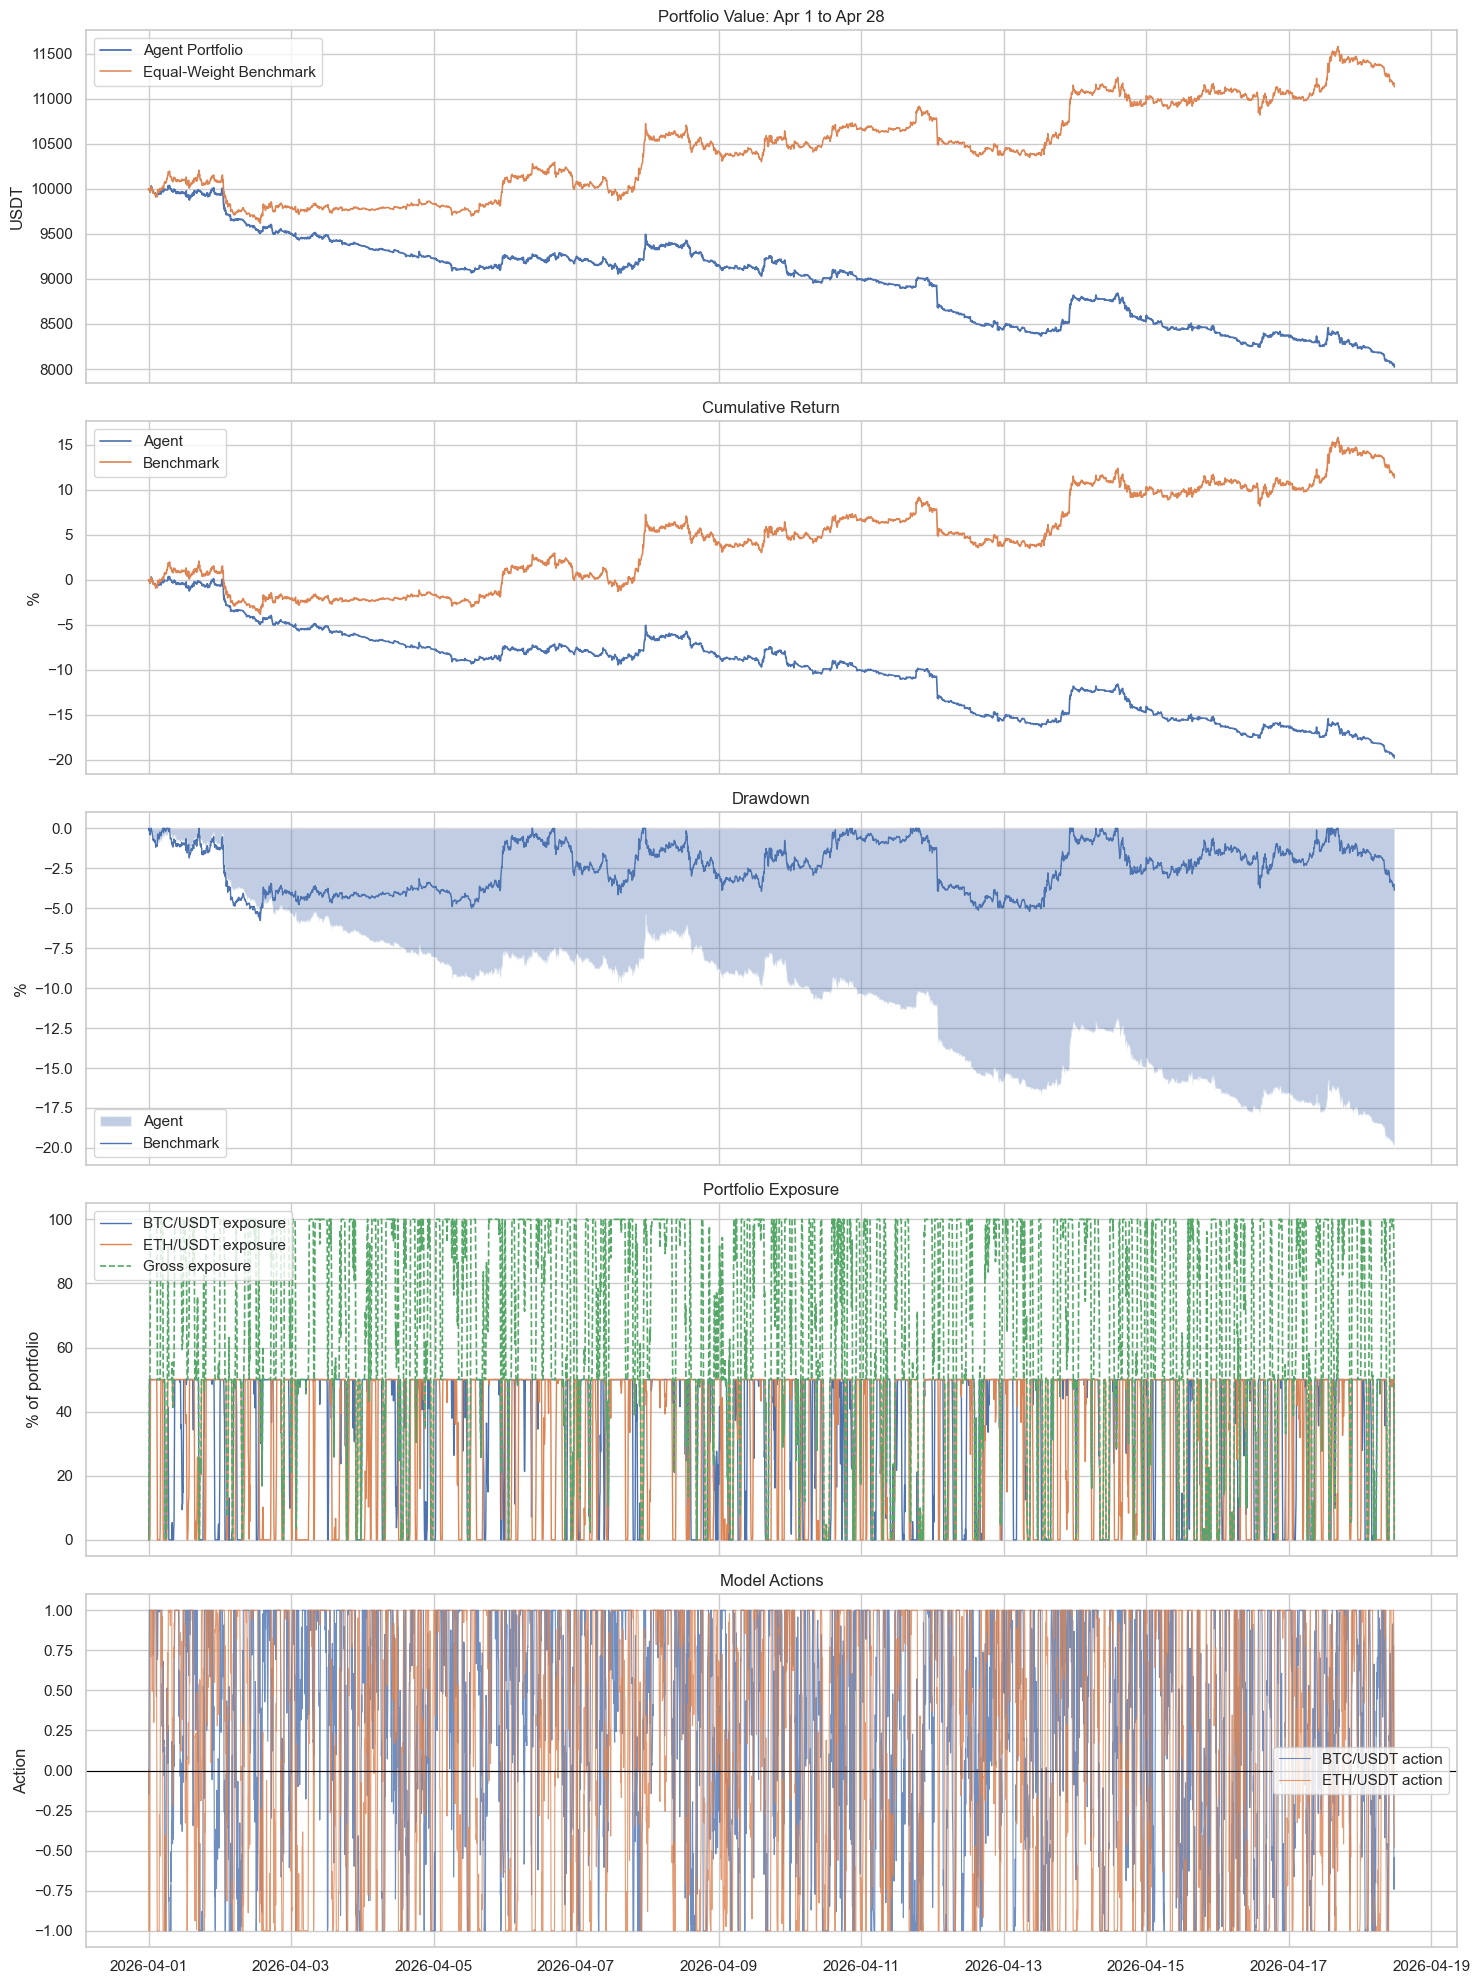

In [ ]:
sns.set_theme(style='whitegrid')

plot_frame = test_results.copy()
plot_frame['datetime'] = pd.to_datetime(plot_frame['datetime'], utc=True)
rolling_window = 12 * 24 * 7
plot_frame['agent_7d_return'] = plot_frame['portfolio_value'] / plot_frame['portfolio_value'].shift(rolling_window) - 1.0
plot_frame['benchmark_7d_return'] = plot_frame['benchmark_value'] / plot_frame['benchmark_value'].shift(rolling_window) - 1.0

fig, axes = plt.subplots(5, 1, figsize=(15, 20), sharex=True)

axes[0].plot(plot_frame['datetime'], plot_frame['portfolio_value'], label='Agent Portfolio', linewidth=1.3)
axes[0].plot(plot_frame['datetime'], plot_frame['benchmark_value'], label='Equal-Weight Benchmark', linewidth=1.1)
axes[0].set_title('Portfolio Value: Apr 1 to Apr 28')
axes[0].set_ylabel('USDT')
axes[0].legend()

axes[1].plot(plot_frame['datetime'], plot_frame['agent_cumulative_return'] * 100, label='Agent', linewidth=1.2)
axes[1].plot(plot_frame['datetime'], plot_frame['benchmark_cumulative_return'] * 100, label='Benchmark', linewidth=1.2)
axes[1].set_title('Cumulative Return')
axes[1].set_ylabel('%')
axes[1].legend()

axes[2].fill_between(plot_frame['datetime'], plot_frame['agent_drawdown'] * 100, 0, alpha=0.35, label='Agent')
axes[2].plot(plot_frame['datetime'], plot_frame['benchmark_drawdown'] * 100, label='Benchmark', linewidth=1.0)
axes[2].set_title('Drawdown')
axes[2].set_ylabel('%')
axes[2].legend()

for symbol in SYMBOLS:
    slug = symbol_slug(symbol)
    axes[3].plot(plot_frame['datetime'], plot_frame[f'exposure_{slug}'] * 100, label=f'{symbol} exposure', linewidth=1.0)
axes[3].plot(plot_frame['datetime'], plot_frame['gross_exposure'] * 100, label='Gross exposure', linewidth=1.2, linestyle='--')
axes[3].set_title('Portfolio Exposure')
axes[3].set_ylabel('% of portfolio')
axes[3].legend()

for symbol in SYMBOLS:
    slug = symbol_slug(symbol)
    axes[4].plot(plot_frame['datetime'], plot_frame[f'action_{slug}'], label=f'{symbol} action', linewidth=0.8, alpha=0.8)
axes[4].axhline(0, color='black', linewidth=0.8)
axes[4].set_title('Model Actions')
axes[4].set_ylabel('Action')
axes[4].legend()

plt.tight_layout()
combined_plot_path = PLOT_DIR / f'{MODEL_NAME}_test_2026_0401_0428_analysis.png'
fig.savefig(combined_plot_path, dpi=180, bbox_inches='tight')
plt.show()


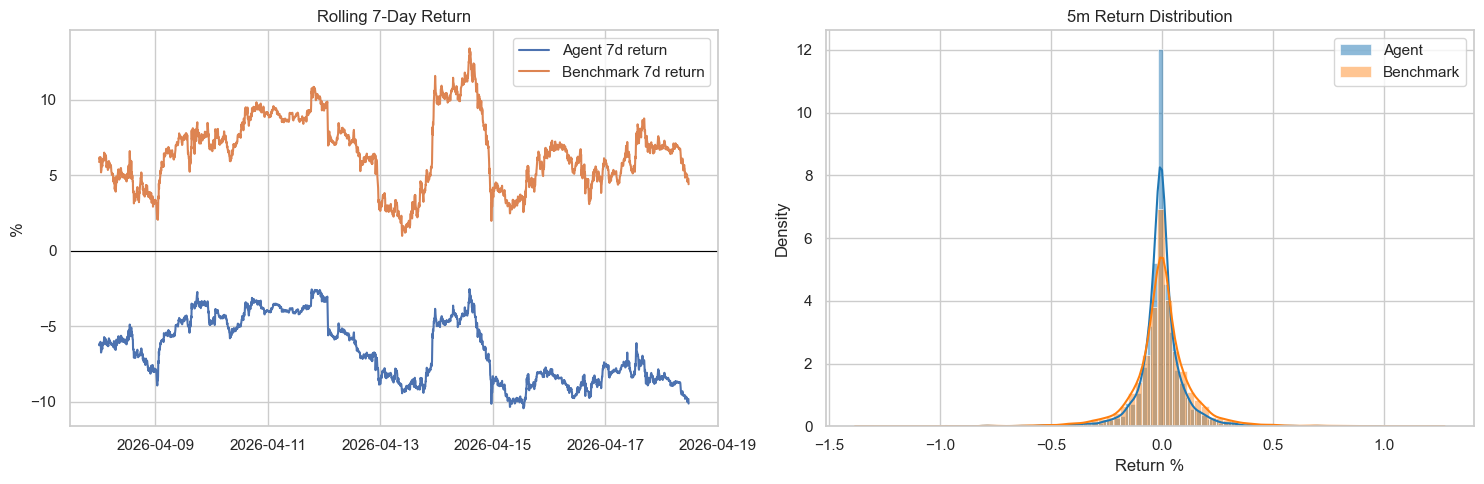

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(plot_frame['datetime'], plot_frame['agent_7d_return'] * 100, label='Agent 7d return')
axes[0].plot(plot_frame['datetime'], plot_frame['benchmark_7d_return'] * 100, label='Benchmark 7d return')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Rolling 7-Day Return')
axes[0].set_ylabel('%')
axes[0].legend()

sns.histplot(plot_frame['agent_return'] * 100, bins=80, kde=True, ax=axes[1], label='Agent', color='tab:blue', stat='density')
sns.histplot(plot_frame['benchmark_return'] * 100, bins=80, kde=True, ax=axes[1], label='Benchmark', color='tab:orange', stat='density', alpha=0.45)
axes[1].set_title('5m Return Distribution')
axes[1].set_xlabel('Return %')
axes[1].legend()

plt.tight_layout()
risk_plot_path = PLOT_DIR / f'{MODEL_NAME}_test_2026_0401_0428_risk_diagnostics.png'
fig.savefig(risk_plot_path, dpi=180, bbox_inches='tight')
plt.show()


## Artifact Summary



In [ ]:
artifact_summary = {
    'model_zip': str(MODEL_PATH) + '.zip',
    'training_summary': str(MODEL_DIR / f'{MODEL_NAME}_training_summary.json'),
    'test_results_csv': str(test_csv_path),
    'test_metrics_json': str(metrics_path),
    'combined_analysis_plot': str(combined_plot_path),
    'risk_diagnostics_plot': str(risk_plot_path),
    'train_processed_bundle': str(train_bundle['root']),
    'test_processed_bundle': str(test_bundle['root']),
}
display(pd.DataFrame(artifact_summary.items(), columns=['artifact', 'path']))
with (REPORT_DIR / f'{MODEL_NAME}_artifact_summary.json').open('w', encoding='utf-8') as handle:
    json.dump(artifact_summary, handle, indent=2)
print(f"Saved artifact summary: {REPORT_DIR / f'{MODEL_NAME}_artifact_summary.json'}")


,artifact,path
0,model_zip,G:\My Drive\ProfitPilot\models\local_5m_2024_2...
1,training_summary,G:\My Drive\ProfitPilot\models\local_5m_2024_2...
2,test_results_csv,G:\My Drive\ProfitPilot\reports\local_5m_2024_...
3,test_metrics_json,G:\My Drive\ProfitPilot\reports\local_5m_2024_...
4,combined_analysis_plot,G:\My Drive\ProfitPilot\reports\local_5m_2024_...
5,risk_diagnostics_plot,G:\My Drive\ProfitPilot\reports\local_5m_2024_...
6,train_processed_bundle,G:\My Drive\ProfitPilot\data\processed_local_5...
7,test_processed_bundle,G:\My Drive\ProfitPilot\data\processed_local_5...


Saved artifact summary: G:\My Drive\ProfitPilot\reports\local_5m_2024_2026\profit_pilot_ppo_5m_local_2024_2026_cash_allocation_artifact_summary.json


## Optional: Final Full-Window Retrain



In [ ]:
if RUN_FINAL_FULL_WINDOW_RETRAIN:
    full_frames = split_symbol_frames(full_symbol_frames, DATA_START_ISO, DATA_END_ISO, inclusive_end=True)
    full_bundle, _ = build_normalized_feature_bundle(
        full_frames,
        PROCESSED_FULL_ROOT,
        DATA_START_ISO,
        DATA_END_ISO,
        label='full_2024_0101_2026_0428',
    )
    full_env = make_vec_env(full_bundle)
    final_name = f'{MODEL_NAME}_full_window'
    final_path = MODEL_DIR / final_name
    if USE_LSTM:
        final_model = RecurrentPPO(
            'MlpLstmPolicy',
            env=full_env,
            verbose=1,
            learning_rate=5e-5,
            n_steps=4096,
            batch_size=1024,
            gamma=0.995,
            gae_lambda=0.95,
            clip_range=0.1,
            ent_coef=0.0005,
            target_kl=0.02,
            device=DEVICE,
        )
    else:
        final_model = PPO(
            'MlpPolicy',
            env=full_env,
            verbose=1,
            learning_rate=5e-5,
            n_steps=4096,
            batch_size=1024,
            gamma=0.995,
            gae_lambda=0.95,
            clip_range=0.1,
            ent_coef=0.0005,
            target_kl=0.02,
            device=DEVICE,
            policy_kwargs={'net_arch': [256, 256]},
        )
    final_model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
    final_model.save(final_path)
    full_env.close()
    print(f'Saved final full-window model: {final_path}.zip')
else:
    print('Skipped final full-window retrain. Set PROFIT_PILOT_FULL_WINDOW_RETRAIN=1 after the test metrics are acceptable.')


Skipped final full-window retrain. Set PROFIT_PILOT_FULL_WINDOW_RETRAIN=1 after the test metrics are acceptable.
